In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix



In [2]:
df = pd.read_csv('data_set/dating_app_behavior_encoded.csv')

print(f"Dataset loaded successfully with shape: {df.shape}")

Dataset loaded successfully with shape: (50000, 80)


In [3]:

X = df.drop(columns=['match_outcomes', 'interest_tags'], errors='ignore')
y = df['match_outcomes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")

Training set size: (40000, 78)


In [4]:
print("Start model tuning, please wait......")
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Tuning completed! Best parameters: {grid_search.best_params_}")

Start model tuning, please wait......
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tuning completed! Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}



--- Random Forest Evaluation Results ---
Accuracy: 0.1006

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.12      0.12      0.12      1010
           1       0.10      0.10      0.10      1005
           2       0.10      0.10      0.10      1004
           3       0.11      0.10      0.11       984
           4       0.08      0.07      0.08       992
           5       0.11      0.11      0.11      1016
           6       0.12      0.12      0.12       998
           7       0.09      0.09      0.09       997
           8       0.09      0.10      0.10      1022
           9       0.10      0.09      0.09       972

    accuracy                           0.10     10000
   macro avg       0.10      0.10      0.10     10000
weighted avg       0.10      0.10      0.10     10000



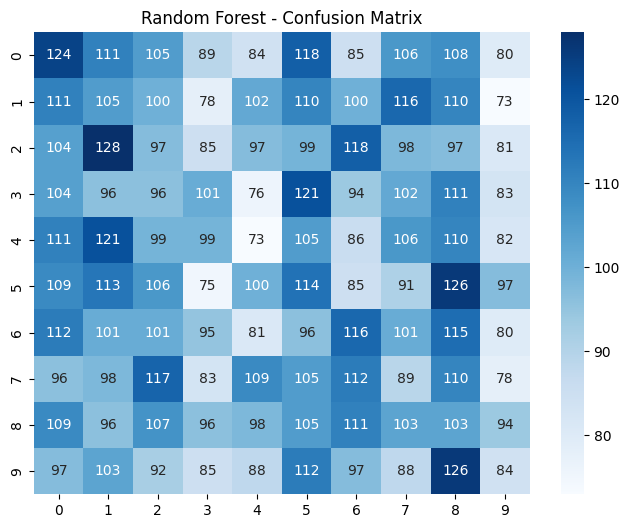

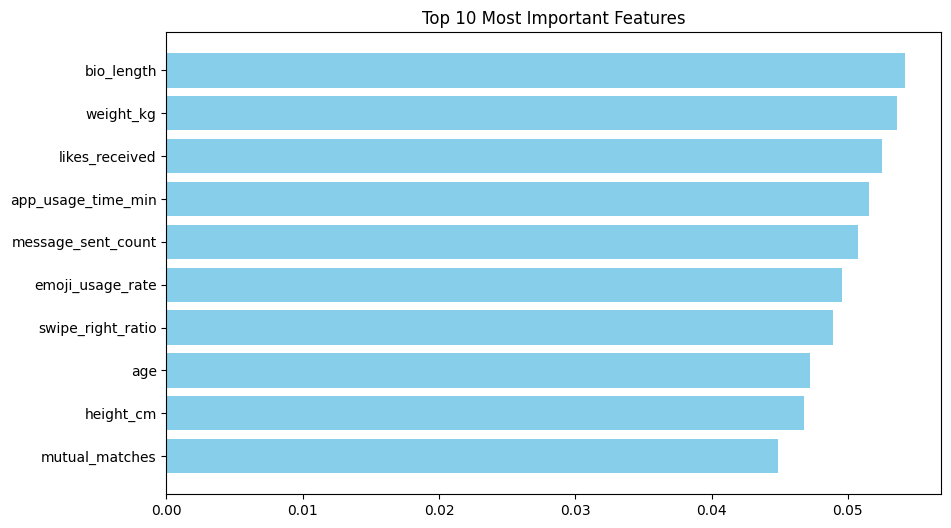

In [5]:
y_pred = best_rf.predict(X_test_scaled)

print("\n--- Random Forest Evaluation Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))


plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()


plt.figure(figsize=(10, 6))
importances = best_rf.feature_importances_
indices = np.argsort(importances)[-10:] 
plt.barh(range(len(indices)), importances[indices], color='skyblue')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title('Top 10 Most Important Features')
plt.show()
